# Регуляризація та функції активації в нейронних мережах


## Бізнес-контекст
Компанія HealthRisk Analytics продовжує покращувати модель прогнозування медичних ризиків.
Команда розробників хоче зрозуміти, як різні функції активації та прийоми регуляризації (Dropout, Batch Normalization) впливають на стабільність і якість навчання моделі. Ваше завдання — провести серію експериментів і порівняти результати.

## Завдання 1
Дослідіть вплив функцій активації на результати моделі.
- Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42).
- Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
- Послідовно застосуйте різні функції активації: ReLU, Tanh, LeakyReLU, Swish.
- Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
- Оформіть результати в таблиці:

|Активація|MAE|R²|
|-|-|-|
|ReLU|...|...|
|Tanh|...|...|
|LeakyReLU|...|...|
|Swish|...|...|

In [1]:
# Згенеруйте синтетичні дані для регресії за допомогою функції make_regression (2000 рядків, 10 ознак, noise=10, random_state=42)
from sklearn.datasets import make_regression
X, y = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
X[0]

array([-1.38301781, -0.18140603,  0.73752806,  0.27524869,  0.51141526,
        1.50808285,  0.60673   ,  0.94782078, -2.09317802, -1.07681697])

In [2]:
# для оцінювання якості навчання розділяємо дані на навчальні та тестові
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train: {len(xtrain)}, test: {len(xtest)}")

train: 1600, test: 400


In [3]:
# готуємо функції активації ReLU, Tanh, LeakyReLU, Swish.
import torch.nn as nn
activators = {
    "Sigmoid": nn.Sigmoid(),
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(),
    "Swish": nn.SiLU(),
}

In [4]:
# Побудуйте модель MLP з одним прихованим прошарком із 32 нейронів.
class Mlp(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activator="Sigmoid"):
        super(Mlp,self).__init__()
        self.activation = activators.get(activator, None)
        if self.activation is None:
            raise ValueError("Undefined activator " + activator)
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            self.activation,
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.layers(x)

In [5]:
# для навчання нейромережі дані мають бути тензорами
import torch
xtrain = torch.tensor(xtrain, dtype=torch.float32)
xtest  = torch.tensor(xtest,  dtype=torch.float32)
ytrain = torch.tensor(ytrain, dtype=torch.float32).reshape(-1,1)
ytest  = torch.tensor(ytest,  dtype=torch.float32).reshape(-1,1)

In [6]:
# для роботи з множиною об'єктів-моделей створимо функцію навчання моделі
def train_model(model, X, y, epochs=1000, lr=0.01):
    loss_f = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        output = model(X)
        loss = loss_f(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

In [7]:
# створюємо перелік моделей з різними фукціями активації
models = [Mlp(activator=k) for k in activators.keys()]
models

[Mlp(
   (activation): Sigmoid()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Sigmoid()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): ReLU()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): Tanh()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): Tanh()
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): LeakyReLU(negative_slope=0.01)
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): LeakyReLU(negative_slope=0.01)
     (2): Linear(in_features=32, out_features=1, bias=True)
   )
 ),
 Mlp(
   (activation): SiLU()
   (layers): Sequential(
     (0): Linear(in_features=10, out_features=32, bias=True)
     (1): SiLU()
     

In [8]:
losses = [train_model(m, xtrain, ytrain) for m in models]
print(*zip(*(ls[:15] for ls in losses)), sep='\n')

(40287.4765625, 40275.3515625, 40262.33984375, 40253.953125, 40310.671875)
(40143.171875, 39646.57421875, 39158.515625, 39342.71484375, 39659.19140625)
(39786.83984375, 32520.912109375, 31213.568359375, 28876.787109375, 32490.1875)
(38834.07421875, 6855.1455078125, 17623.58984375, 14670.1083984375, 3055.821044921875)
(36897.1640625, 80983.5703125, 10847.6884765625, 32122.8671875, 21921.7265625)
(33923.125, 40252.92578125, 8346.8154296875, 9234.8046875, 23675.34765625)
(30333.994140625, 37000.5078125, 7054.35107421875, 32695.060546875, 52709.60546875)
(26656.154296875, 29814.845703125, 9416.4580078125, 39838.296875, 258167.765625)
(23234.2890625, 28480.400390625, 31709.904296875, 38812.93359375, 6023838.5)
(20236.810546875, 60142.953125, 8508.19921875, 30594.828125, 542186471424.0)
(17720.64453125, 77744.578125, 6572.921875, 30975.341796875, 1.854063209808663e+27)
(15663.677734375, 211142.953125, 5672.18603515625, 57562.24609375, inf)
(14004.5400390625, 49160.01953125, 5078.8671875, 816

In [9]:
import matplotlib.pyplot as plt
labels = list(activators.keys())

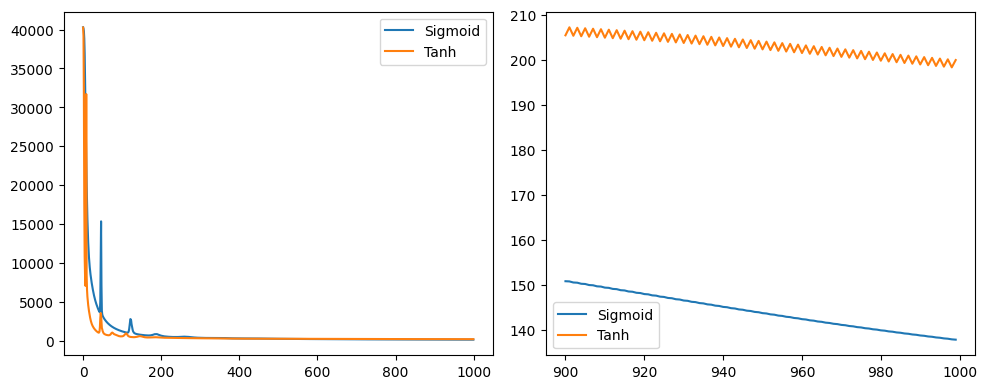

In [10]:
_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in (0, 2):
    ax.plot(range(1000), losses[i], label=labels[i])
ax.legend()
for i in (0, 2):
    ax2.plot(range(900,1000), losses[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

Ефект "вибуху градієнту" виникає при великих величинах входу і призводить до того, що модель не навчається. Напрямки дій - а) зменшити learning rate, б) масштабувати дані (вхідні)

In [11]:
# Використаємо масштабування (нормалізацію) даних
X2, y2 = make_regression(n_samples=2000, n_features=10, noise=10, random_state=42)
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(X2, y2, test_size=0.2, random_state=42)
 
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
xtrain2 = scaler_x.fit_transform(xtrain2)  # навчаємо scaler на навчальній вибірці
xtest2 = scaler_x.transform(xtest2)        # для тестової - вживаємо навчений scaler
scaler_y = StandardScaler()
ytrain2 = scaler_y.fit_transform(ytrain2.reshape(-1,1))  # навчаємо scaler на навчальній вибірці
ytest2 = scaler_y.transform(ytest2.reshape(-1,1))        # для тестової - вживаємо навчений scaler
 
xtrain2 = torch.tensor(xtrain2, dtype=torch.float32)
xtest2  = torch.tensor(xtest2,  dtype=torch.float32)
ytrain2 = torch.tensor(ytrain2, dtype=torch.float32) 
ytest2  = torch.tensor(ytest2,  dtype=torch.float32)

models2 = [Mlp(activator=k) for k in activators.keys()]
losses2 = [train_model(m, xtrain2, ytrain2) for m in models2]
print(*zip(*(ls[:15] for ls in losses2)), sep='\n')

(0.956788182258606, 1.129146933555603, 1.2343378067016602, 1.1863760948181152, 0.930055558681488)
(0.930698573589325, 1.1090706586837769, 1.1917357444763184, 1.171429991722107, 0.9163480401039124)
(0.9125979542732239, 1.0898691415786743, 1.1514705419540405, 1.1570072174072266, 0.9028865098953247)
(0.8998115658760071, 1.0714565515518188, 1.1133489608764648, 1.1430668830871582, 0.8896582722663879)
(0.8905595541000366, 1.0537583827972412, 1.0771970748901367, 1.1295676231384277, 0.8766514658927917)
(0.8836585283279419, 1.0367014408111572, 1.0428577661514282, 1.1164740324020386, 0.8638550639152527)
(0.8783211708068848, 1.0202274322509766, 1.0101895332336426, 1.1037511825561523, 0.8512585163116455)
(0.8740234971046448, 1.0042781829833984, 0.979063868522644, 1.091367483139038, 0.8388525247573853)
(0.8704169988632202, 0.988802969455719, 0.9493649005889893, 1.0792953968048096, 0.8266280889511108)
(0.8672700524330139, 0.9737588763237, 0.9209873676300049, 1.0675053596496582, 0.8145768642425537)
(

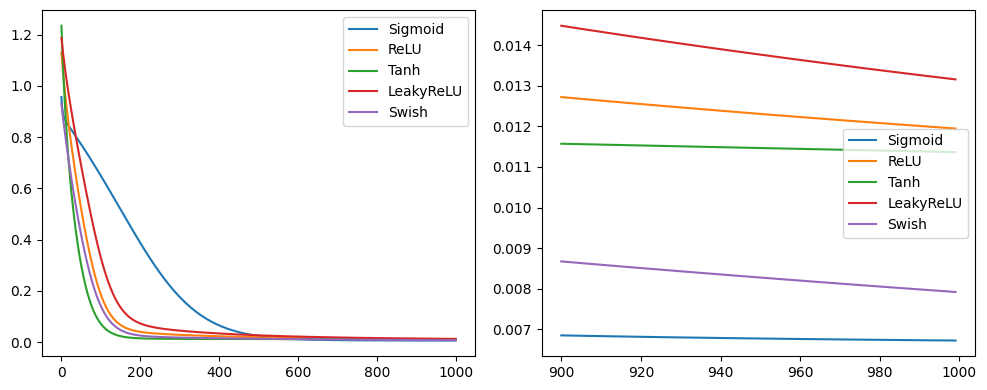

In [12]:

_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in range(len(activators)):
    ax.plot(range(1000), losses2[i], label=labels[i])
ax.legend()
for i in range(len(activators)):
    ax2.plot(range(900,1000), losses2[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

In [13]:
# Для кожної активації розрахуйте MAE і R² на тестовій вибірці.
import sklearn.metrics as sm
predictions = [m(xtest2) for m in models2]
with torch.no_grad():
    mae_scores = [sm.mean_absolute_error(ytest2, p) for p in predictions]
    r2_scores = [sm.r2_score(ytest2, p) for p in predictions]

from IPython.display import Markdown as md
md("\n".join((
    "|Активація|MAE|R²|",
    "|-|-|-|",
    *(f"|{labels[i]}|{mae_scores[i]}|{r2_scores[i]}|" for i in range(len(activators)))
)))

|Активація|MAE|R²|
|-|-|-|
|Sigmoid|0.05304838344454765|0.9945845007896423|
|ReLU|0.09105058759450912|0.9856720566749573|
|Tanh|0.07422082126140594|0.9892512559890747|
|LeakyReLU|0.09315261244773865|0.98421710729599|
|Swish|0.06959415227174759|0.9910110235214233|

**Регуляризація** нейронних мереж - заходи зі зменшенняя ефекту "Перенавчання" мереж, за якого мережа 
"запам'ятовує" усі навчальні дані і адаптується тільки до них, погіршуючи прогнози для тестових даних.

**Dropout** - випадкове виключення: під час кожної епохи навчання випадковим типом "розриваються" певні
зв'язки (вагові коефіцієнти вважаються нульовими при розрахунках)

**L1 \ L2**регуляризація: L1 - Lasso, L2 - Ridge.Введення  "штрафів" за надто великі ваги нейронів.

**Рання зупинка** - навчання припиняється коли функція втрат починає зростати після тривалого зменшення.

****

## Завдання 2
Додайте Dropout і проаналізуйте вплив регуляризації.

- Використовуйте ту саму архітектуру MLP.
- Додайте шар torch.nn.Dropout(p=0.3) після прихованого шару.
- Порівняйте результати до і після застосування Dropout за MAE і R².
- Зробіть висновок: чи допомагає Dropout уникнути перенавчання?

In [14]:
class MlpDropout(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activator="Sigmoid"):
        super(MlpDropout,self).__init__()
        self.activation = activators.get(activator, None)
        if self.activation is None:
            raise ValueError("Undefined activator " + activator)
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x, mode="test"):
        x = self.layer1(x)
        x = self.activation(x)
        if(mode != "test"):
            x = self.dropout(x)
        x = self.layer2(x)
        return x

In [15]:
def train_model_reg(model, X, y, epochs=1000, lr=0.01):
    loss_f = nn.functional.mse_loss
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for epoch in range(epochs):
        output = model(X, 'train')
        loss = loss_f(output, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

In [16]:
models_d = [MlpDropout(activator=k) for k in activators.keys()]
losses_d = [train_model_reg(m, xtrain2, ytrain2) for m in models_d]
print(*zip(*(ls[:15] for ls in losses_d)), sep='\n')

(1.3472449779510498, 1.3167822360992432, 1.1706748008728027, 0.9884678721427917, 1.0017082691192627)
(1.242972731590271, 1.2834255695343018, 1.1362884044647217, 0.9568099975585938, 1.010248064994812)
(1.1849708557128906, 1.234889030456543, 1.0795036554336548, 0.9546552300453186, 0.9841330647468567)
(1.1590774059295654, 1.251886010169983, 1.0511183738708496, 0.9104756712913513, 0.9782257080078125)
(1.1204767227172852, 1.207552194595337, 1.0077229738235474, 0.9084513783454895, 0.953708827495575)
(1.0880188941955566, 1.182961106300354, 0.9812338352203369, 0.8738149404525757, 0.953900158405304)
(1.0574584007263184, 1.17324697971344, 0.949293315410614, 0.8685560822486877, 0.9375606775283813)
(1.0808920860290527, 1.1466342210769653, 0.9289934039115906, 0.8469539880752563, 0.912060022354126)
(1.0475326776504517, 1.1224894523620605, 0.8815563321113586, 0.8372190594673157, 0.8929778337478638)
(1.0459144115447998, 1.125328540802002, 0.8577246069908142, 0.8302168250083923, 0.8926061987876892)
(1.

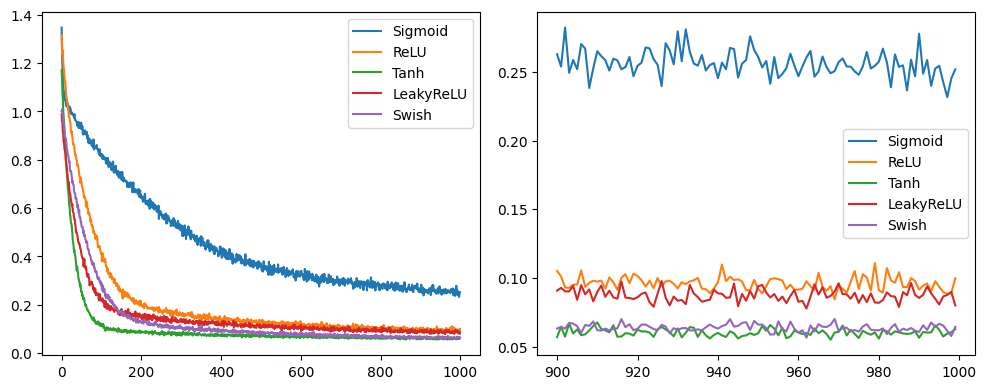

In [17]:
_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in range(len(activators)):
    ax.plot(range(1000), losses_d[i], label=labels[i])
ax.legend()
for i in range(len(activators)):
    ax2.plot(range(900,1000), losses_d[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

In [18]:
predictions_d = [m(xtest2) for m in models_d]
with torch.no_grad():
    mae_scores_d = [sm.mean_absolute_error(ytest2, p) for p in predictions_d]
    r2_scores_d = [sm.r2_score(ytest2, p) for p in predictions_d]
 
from IPython.display import Markdown as md
md("\n".join((
    "|Активація|MAE|R²|MAE Dropout|R² Dropout|",
    "|-|-|-|-|-|",
    *("|%s|%.3f|%.3f|%.3f|%.3f|" % (
        labels[i],
        mae_scores[i],
        r2_scores[i],
        mae_scores_d[i],
        r2_scores_d[i]
    ) for i in range(len(activators)))
)))

|Активація|MAE|R²|MAE Dropout|R² Dropout|
|-|-|-|-|-|
|Sigmoid|0.053|0.995|0.161|0.944|
|ReLU|0.091|0.986|0.100|0.980|
|Tanh|0.074|0.989|0.070|0.989|
|LeakyReLU|0.093|0.984|0.089|0.985|
|Swish|0.070|0.991|0.068|0.991|

## Завдання 3
Додайте Batch Normalization для стабілізації навчання.

- Використовуйте шар torch.nn.BatchNorm1d після лінійного шару.
- Навчіть модель і побудуйте графік функції втрат за епохами.
- Порівняйте розкид loss з попередніми експериментами.

In [19]:
class MlpBatch(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activator="Sigmoid"):
        super(MlpBatch,self).__init__()
        self.activation = activators.get(activator, None)
        if self.activation is None:
            raise ValueError("Undefined activator " + activator)
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.batch = nn.BatchNorm1d(hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x, mode="test"):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.batch(x)
        # if(mode != "test"):
            
        x = self.layer2(x)
        return x

In [20]:
models_b = [MlpBatch(activator=k) for k in activators.keys()]
losses_b = [train_model_reg(m, xtrain2, ytrain2) for m in models_b]
print(*zip(*(ls[:15] for ls in losses_b)), sep='\n')

(1.639829158782959, 1.7159910202026367, 1.6409125328063965, 2.197254180908203, 1.4532279968261719)
(1.3841084241867065, 1.5154720544815063, 1.351596713066101, 1.9121938943862915, 1.2094348669052124)
(1.1801413297653198, 1.3460731506347656, 1.122410535812378, 1.6861799955368042, 1.0200254917144775)
(1.014750361442566, 1.2014880180358887, 0.9382237195968628, 1.5037628412246704, 0.8703969717025757)
(0.8787226676940918, 1.0771913528442383, 0.7884848117828369, 1.3539283275604248, 0.7504196763038635)
(0.7654569149017334, 0.9696260690689087, 0.6656215190887451, 1.228951334953308, 0.6529096364974976)
(0.6701219081878662, 0.8758822083473206, 0.5640609264373779, 1.1233047246932983, 0.5726786851882935)
(0.5891174077987671, 0.7935985326766968, 0.479610413312912, 1.0329022407531738, 0.5059221386909485)
(0.5197168588638306, 0.7210307121276855, 0.40905433893203735, 0.9547590017318726, 0.44981181621551514)
(0.45982661843299866, 0.6567752361297607, 0.34988343715667725, 0.8864871859550476, 0.40222042798

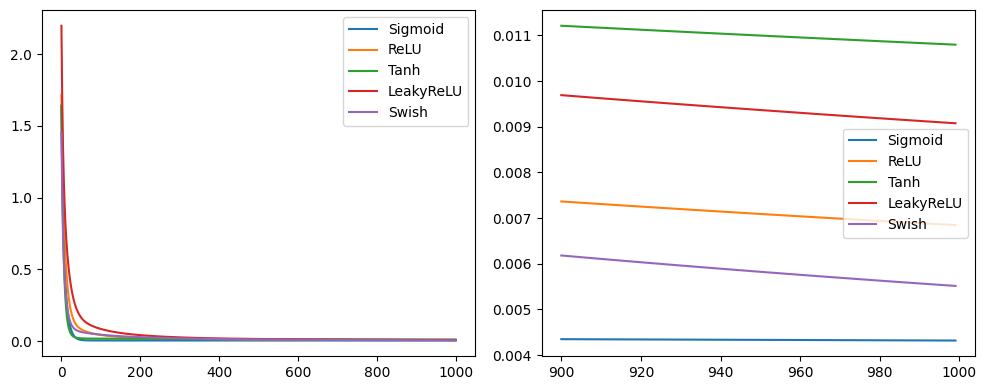

In [21]:
_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in range(len(activators)):
    ax.plot(range(1000), losses_b[i], label=labels[i])
ax.legend()
for i in range(len(activators)):
    ax2.plot(range(900,1000), losses_b[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

In [22]:
predictions_b = [m(xtest2) for m in models_b]
with torch.no_grad():
    mae_scores_b = [sm.mean_absolute_error(ytest2, p) for p in predictions_b]
    r2_scores_b = [sm.r2_score(ytest2, p) for p in predictions_b]
 
from IPython.display import Markdown as md
md("\n".join((
    "|Активація|MAE|R²|MAE Dropout|R² Dropout|MAE Batch|R² Batch",
    "|-|-|-|-|-|-|-|",
    *("|%s|%.3f|%.3f|%.3f|%.3f|%.3f|%.3f|" % (
        labels[i],
        mae_scores[i],
        r2_scores[i],
        mae_scores_d[i],
        r2_scores_d[i],
        mae_scores_b[i],
        r2_scores_b[i]
    ) for i in range(len(activators)))
)))

|Активація|MAE|R²|MAE Dropout|R² Dropout|MAE Batch|R² Batch
|-|-|-|-|-|-|-|
|Sigmoid|0.053|0.995|0.161|0.944|0.053|0.995|
|ReLU|0.091|0.986|0.100|0.980|0.075|0.990|
|Tanh|0.074|0.989|0.070|0.989|0.073|0.990|
|LeakyReLU|0.093|0.984|0.089|0.985|0.084|0.987|
|Swish|0.070|0.991|0.068|0.991|0.061|0.993|

In [23]:
class MlpBatchDropout(nn.Module):
    def __init__(self, input_size=10, hidden_size=32, output_size=1, activator="Sigmoid"):
        super(MlpBatchDropout,self).__init__()
        self.activation = activators.get(activator, None)
        if self.activation is None:
            raise ValueError("Undefined activator " + activator)
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.batch = nn.BatchNorm1d(hidden_size)
        self.dropout = torch.nn.Dropout(p=0.3)
        self.layer2 = nn.Linear(hidden_size, output_size)

    def forward(self, x, mode="test"):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.batch(x)
        x = self.dropout(x)
        #if(mode != "test"):
            
        x = self.layer2(x)
        return x

In [24]:
models_bd = [MlpBatchDropout(activator=k) for k in activators.keys()]
losses_bd = [train_model_reg(m, xtrain2, ytrain2) for m in models_bd]
print(*zip(*(ls[:15] for ls in losses_bd)), sep='\n')

(1.8017396926879883, 1.3706717491149902, 1.5547031164169312, 1.7149218320846558, 1.7279369831085205)
(1.500532865524292, 1.1820499897003174, 1.190067172050476, 1.5171935558319092, 1.444466233253479)
(1.1776329278945923, 1.078375220298767, 0.9101393222808838, 1.3489527702331543, 1.2607046365737915)
(1.01139497756958, 0.9597242474555969, 0.7260489463806152, 1.1931827068328857, 1.0832726955413818)
(0.8338156342506409, 0.8855152726173401, 0.574245810508728, 1.051499366760254, 0.915077269077301)
(0.7434297204017639, 0.8062551617622375, 0.4840855896472931, 0.9749345183372498, 0.8072817325592041)
(0.6591430902481079, 0.7391931414604187, 0.39872291684150696, 0.8825000524520874, 0.7624590396881104)
(0.5490727424621582, 0.6796477437019348, 0.35236886143684387, 0.7901731729507446, 0.6533159017562866)
(0.5095317959785461, 0.62809157371521, 0.3127630352973938, 0.7447047233581543, 0.6101866960525513)
(0.47417980432510376, 0.5836111903190613, 0.2616579532623291, 0.6814169883728027, 0.5372753739356995

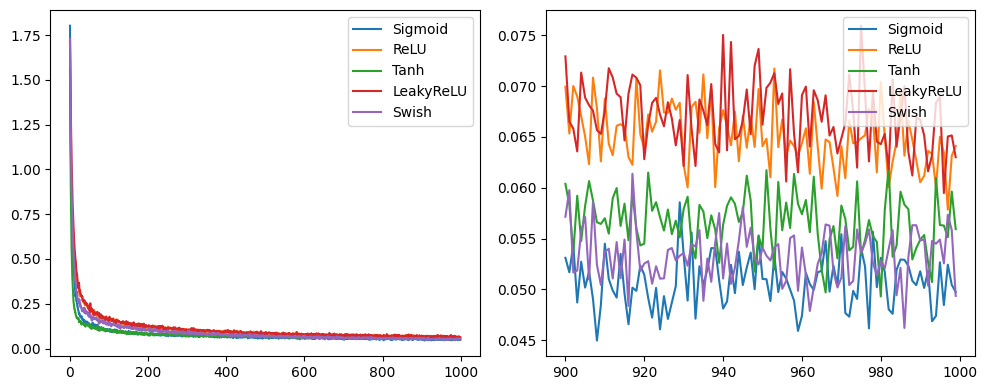

In [25]:
_,(ax, ax2) = plt.subplots(1,2, figsize=(10,4))
for i in range(len(activators)):
    ax.plot(range(1000), losses_bd[i], label=labels[i])
ax.legend()
for i in range(len(activators)):
    ax2.plot(range(900,1000), losses_bd[i][900:], label=labels[i])
ax2.legend()
plt.tight_layout()
plt.show()

In [26]:
predictions_bd = [m(xtest2) for m in models_bd]
with torch.no_grad():
    mae_scores_bd = [sm.mean_absolute_error(ytest2, p) for p in predictions_bd]
    r2_scores_bd = [sm.r2_score(ytest2, p) for p in predictions_bd]

md("\n".join((
    "|Активація|MAE|R²|MAE Dropout|R² Dropout|MAE Batch|R² Batch|MAE Batch Dropout|R² Batch Dropout|",
    "|-|-|-|-|-|-|-|-|-|",
    *("|%s|%.3f|%.3f|%.3f|%.3f|%.3f|%.3f|%.3f|%.3f|" % (
        labels[i],
        mae_scores[i],
        r2_scores[i],
        mae_scores_d[i],
        r2_scores_d[i],
        mae_scores_b[i],
        r2_scores_b[i],
        mae_scores_bd[i],
        r2_scores_bd[i]
        
    ) for i in range(len(activators)))
)))

|Активація|MAE|R²|MAE Dropout|R² Dropout|MAE Batch|R² Batch|MAE Batch Dropout|R² Batch Dropout|
|-|-|-|-|-|-|-|-|-|
|Sigmoid|0.053|0.995|0.161|0.944|0.053|0.995|0.155|0.953|
|ReLU|0.091|0.986|0.100|0.980|0.075|0.990|0.199|0.926|
|Tanh|0.074|0.989|0.070|0.989|0.073|0.990|0.169|0.950|
|LeakyReLU|0.093|0.984|0.089|0.985|0.084|0.987|0.181|0.937|
|Swish|0.070|0.991|0.068|0.991|0.061|0.993|0.171|0.943|